# ProfitPilot Local 5m PPO Training

This notebook is built for a local Jupyter or VS Code kernel. It downloads BTC/USDT and ETH/USDT 5-minute candles from `2024-01-01` through `2026-04-28`, trains the RL trading model on `2024-01-01` through `2026-03-30`, and tests out of sample on `2026-04-01` through `2026-04-28`.

The notebook automatically uses CUDA when the local PyTorch install can see a compatible GPU; otherwise it falls back to CPU. The out-of-sample split is intentional: training and testing on the same candles would make the result look better than it really is.

In [24]:
# Local setup. Run this in the same environment selected as the notebook kernel.
# This installs the project runtime dependencies without forcing a specific PyTorch/CUDA build.
%pip install -q stable-baselines3 sb3-contrib gymnasium ccxt ta python-dotenv pyyaml pyarrow seaborn tqdm rich ipywidgets tensorboard


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [25]:
from pathlib import Path
import json
import math
import os
import random
import sys
import warnings


def find_project_root() -> Path:
    candidates = []
    env_root = os.environ.get('PROFIT_PILOT_ROOT')
    if env_root:
        candidates.append(Path(env_root).expanduser())
    candidates.append(Path.cwd())

    for candidate in list(candidates):
        candidates.extend(candidate.parents)

    seen = set()
    for candidate in candidates:
        try:
            resolved = candidate.resolve()
        except OSError:
            continue
        if resolved in seen:
            continue
        seen.add(resolved)
        if (resolved / 'src' / 'profit_pilot').exists():
            return resolved

    raise FileNotFoundError(
        'Could not find ProfitPilot. Start the notebook from the project folder or set '
        'PROFIT_PILOT_ROOT to the local project path.'
    )


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print(f'Project root: {PROJECT_ROOT}')

import numpy as np
import pandas as pd
import torch
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch device: {DEVICE}')
if DEVICE == 'cuda':
    if hasattr(torch, 'set_float32_matmul_precision'):
        torch.set_float32_matmul_precision('high')
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA version: {torch.version.cuda}')
else:
    print('CUDA GPU not detected by PyTorch. Training will run on CPU.')

Project root: /Users/dhameliyautskerarjanbhai/Documents/RL_Project/Profit-Pilot
PyTorch device: cpu
CUDA GPU not detected by PyTorch. Training will run on CPU.


In [26]:
import ccxt
import matplotlib.pyplot as plt
import seaborn as sns
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.utils import set_random_seed
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

from profit_pilot.data.download_ohlcv import fetch_symbol_ohlcv, save_symbol_csv
from profit_pilot.env.multi_crypto_env import MultiCryptoTradingEnv
from profit_pilot.features.build_features import (
    BASE_FEATURE_COLUMNS,
    add_technical_indicators,
    align_frames,
    build_arrays,
)
from profit_pilot.utils.io import bundle_directory, save_json, symbol_slug


def env_flag(name: str, default: bool = False) -> bool:
    value = os.environ.get(name)
    if value is None:
        return default
    return value.strip().lower() in {'1', 'true', 'yes', 'y', 'on'}


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_random_seed(SEED)

EXCHANGE_IDS = [
    exchange_id.strip()
    for exchange_id in os.environ.get('PROFIT_PILOT_EXCHANGES', 'binanceus,kucoin,okx,bybit,binance').split(',')
    if exchange_id.strip()
]
EXCHANGE_ID = EXCHANGE_IDS[0]
SYMBOLS = ['BTC/USDT', 'ETH/USDT']
TIMEFRAME = '5m'
DOWNLOAD_LIMIT = 1000

DATA_START_ISO = '2024-01-01T00:00:00Z'
TRAIN_END_ISO = '2026-03-30T23:55:00Z'
TEST_WARMUP_START_ISO = '2026-03-31T00:00:00Z'
TEST_START_ISO = '2026-04-01T00:00:00Z'
TEST_END_ISO = '2026-04-28T00:00:00Z'
DATA_END_ISO = TEST_END_ISO

INITIAL_CASH = 10_000.0
LOOKBACK = 96
TOTAL_TIMESTEPS = 500_000
TRAIN_MODEL = not env_flag('PROFIT_PILOT_SKIP_TRAINING', default=False)
USE_LSTM = True
FORCE_REDOWNLOAD = env_flag('PROFIT_PILOT_FORCE_REDOWNLOAD', default=False)
RUN_FINAL_FULL_WINDOW_RETRAIN = env_flag('PROFIT_PILOT_FULL_WINDOW_RETRAIN', default=False)

RAW_ROOT = PROJECT_ROOT / 'data' / 'raw_local_5m_2024_2026'
PROCESSED_TRAIN_ROOT = PROJECT_ROOT / 'data' / 'processed_local_5m_train_2024_2026_0330'
PROCESSED_TEST_ROOT = PROJECT_ROOT / 'data' / 'processed_local_5m_test_2026_0401_0428'
PROCESSED_FULL_ROOT = PROJECT_ROOT / 'data' / 'processed_local_5m_full_2024_2026_0428'
MODEL_DIR = PROJECT_ROOT / 'models' / 'local_5m_2024_2026'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'local_5m_2024_2026'
PLOT_DIR = REPORT_DIR / 'plots'
for path in [RAW_ROOT, PROCESSED_TRAIN_ROOT, PROCESSED_TEST_ROOT, PROCESSED_FULL_ROOT, MODEL_DIR, REPORT_DIR, PLOT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

MODEL_NAME = f"profit_pilot_{'recurrent_' if USE_LSTM else ''}ppo_5m_local_2024_2026"
MODEL_PATH = MODEL_DIR / MODEL_NAME

print(f'Exchange fallback order: {EXCHANGE_IDS}')
print(f'Train window: {DATA_START_ISO} to {TRAIN_END_ISO}')
print(f'Test window: {TEST_START_ISO} to {TEST_END_ISO} (warm-up starts {TEST_WARMUP_START_ISO})')
print(f'Total timesteps: {TOTAL_TIMESTEPS:,}')
print(f'Model name: {MODEL_NAME}')
print(f'Reports: {REPORT_DIR}')

Exchange fallback order: ['binanceus', 'kucoin', 'okx', 'bybit', 'binance']
Train window: 2024-01-01T00:00:00Z to 2026-03-30T23:55:00Z
Test window: 2026-04-01T00:00:00Z to 2026-04-28T00:00:00Z (warm-up starts 2026-03-31T00:00:00Z)
Total timesteps: 500,000
Model name: profit_pilot_recurrent_ppo_5m_local_2024_2026
Reports: /Users/dhameliyautskerarjanbhai/Documents/RL_Project/Profit-Pilot/reports/local_5m_2024_2026


## Download and Cache 5m Market Data

This cell uses public OHLCV candles through CCXT and stores them under the local data folder. The notebook tries the configured exchanges in order and uses the first one that works for all symbols.

In [27]:
def create_market_data_exchange(exchange_id: str):
    exchange_class = getattr(ccxt, exchange_id)
    exchange = exchange_class({'enableRateLimit': True})
    exchange.timeout = 30_000
    return exchange


def read_cached_frame(path: Path) -> pd.DataFrame | None:
    if not path.exists() or FORCE_REDOWNLOAD:
        return None

    frame = pd.read_csv(path)
    if frame.empty or 'datetime' not in frame.columns:
        return None

    frame['datetime'] = pd.to_datetime(frame['datetime'], utc=True)
    start = pd.Timestamp(DATA_START_ISO)
    end = pd.Timestamp(DATA_END_ISO)
    if frame['datetime'].min() <= start and frame['datetime'].max() >= end - pd.Timedelta(minutes=5):
        return frame[(frame['datetime'] >= start) & (frame['datetime'] <= end)].copy()
    return None


def load_or_download_symbol(exchange, exchange_id: str, symbol: str) -> pd.DataFrame:
    target_path = RAW_ROOT / exchange_id / TIMEFRAME / f'{symbol_slug(symbol)}.csv'
    cached = read_cached_frame(target_path)
    if cached is not None:
        print(f'Using cached {symbol} from {exchange_id}: {len(cached):,} rows')
        return cached

    print(f'Downloading {symbol} {TIMEFRAME} from {exchange_id}: {DATA_START_ISO} to {DATA_END_ISO}')
    frame = fetch_symbol_ohlcv(
        exchange=exchange,
        symbol=symbol,
        timeframe=TIMEFRAME,
        since=DATA_START_ISO,
        until=DATA_END_ISO,
        limit=DOWNLOAD_LIMIT,
    )
    frame['datetime'] = pd.to_datetime(frame['datetime'], utc=True)
    saved_path = save_symbol_csv(frame, RAW_ROOT, exchange_id, TIMEFRAME, symbol)
    print(f'Saved {len(frame):,} rows to {saved_path}')
    return frame


def download_all_symbols_from_exchange(exchange_id: str) -> dict[str, pd.DataFrame]:
    exchange = create_market_data_exchange(exchange_id)
    try:
        exchange.load_markets()
        available_symbols = set(exchange.symbols or [])
        missing_symbols = [symbol for symbol in SYMBOLS if symbol not in available_symbols]
        if missing_symbols:
            raise ValueError(f'{exchange_id} does not list these symbols: {missing_symbols}')

        return {
            symbol: load_or_download_symbol(exchange, exchange_id, symbol)
            for symbol in SYMBOLS
        }
    finally:
        if hasattr(exchange, 'close'):
            exchange.close()


full_symbol_frames = None
download_errors = {}
for candidate_exchange_id in EXCHANGE_IDS:
    print(f'\nTrying exchange: {candidate_exchange_id}')
    try:
        candidate_frames = download_all_symbols_from_exchange(candidate_exchange_id)
        full_symbol_frames = candidate_frames
        EXCHANGE_ID = candidate_exchange_id
        print(f'Using exchange for this run: {EXCHANGE_ID}')
        break
    except Exception as exc:
        error_message = f'{type(exc).__name__}: {str(exc)}'
        download_errors[candidate_exchange_id] = error_message
        print(f'{candidate_exchange_id} failed: {error_message[:500]}')

if full_symbol_frames is None:
    display(pd.DataFrame(download_errors.items(), columns=['exchange', 'error']))
    raise RuntimeError(
        'No exchange in EXCHANGE_IDS could download all requested symbols. '
        'Try changing EXCHANGE_IDS in Cell 4, for example to ["kucoin", "okx", "bybit"].'
    )

coverage_rows = []
for symbol, frame in full_symbol_frames.items():
    coverage_rows.append({
        'exchange': EXCHANGE_ID,
        'symbol': symbol,
        'rows': len(frame),
        'first': frame['datetime'].min(),
        'last': frame['datetime'].max(),
    })
display(pd.DataFrame(coverage_rows))


Trying exchange: binanceus
Using cached BTC/USDT from binanceus: 244,225 rows
Using cached ETH/USDT from binanceus: 244,225 rows
Using exchange for this run: binanceus


,exchange,symbol,rows,first,last
0,binanceus,BTC/USDT,244225,2024-01-01 00:00:00+00:00,2026-04-28 00:00:00+00:00
1,binanceus,ETH/USDT,244225,2024-01-01 00:00:00+00:00,2026-04-28 00:00:00+00:00


## Build Train and Test Feature Bundles

Technical features are standardized with train-set statistics only. The test bundle includes Mar 31 warm-up candles for indicators and the `LOOKBACK` window, then it is sliced so the test portfolio starts on Apr 1 with fresh cash and zero holdings.

In [28]:
def split_symbol_frames(frames: dict[str, pd.DataFrame], start_iso: str, end_iso: str, inclusive_end: bool) -> dict[str, pd.DataFrame]:
    start = pd.Timestamp(start_iso)
    end = pd.Timestamp(end_iso)
    split_frames = {}
    for symbol, frame in frames.items():
        working = frame.copy()
        working['datetime'] = pd.to_datetime(working['datetime'], utc=True)
        if inclusive_end:
            mask = (working['datetime'] >= start) & (working['datetime'] <= end)
        else:
            mask = (working['datetime'] >= start) & (working['datetime'] < end)
        split = working.loc[mask].sort_values('datetime').reset_index(drop=True)
        if split.empty:
            raise ValueError(f'No rows for {symbol} between {start_iso} and {end_iso}')
        split_frames[symbol] = split
    return split_frames


def build_normalized_feature_bundle(
    symbol_frames: dict[str, pd.DataFrame],
    processed_root: Path,
    source_start_iso: str,
    source_end_iso: str,
    label: str,
    normalization_stats: dict[str, np.ndarray] | None = None,
) -> tuple[dict, dict[str, np.ndarray]]:
    enriched_frames = {}
    for symbol, frame in symbol_frames.items():
        enriched = add_technical_indicators(frame)
        if enriched.empty:
            raise ValueError(f'Feature frame became empty after indicator warm-up: {symbol}')
        enriched_frames[symbol] = enriched

    timestamps, aligned_frames = align_frames(enriched_frames)
    price_array, raw_tech_array, feature_export = build_arrays(SYMBOLS, aligned_frames)

    if normalization_stats is None:
        tech_mean = raw_tech_array.mean(axis=0)
        tech_std = raw_tech_array.std(axis=0)
        tech_std = np.where(tech_std < 1e-8, 1.0, tech_std)
        normalization_stats = {'mean': tech_mean, 'std': tech_std}

    tech_array = ((raw_tech_array - normalization_stats['mean']) / normalization_stats['std']).astype(np.float32)
    price_array = price_array.astype(np.float32)

    output_dir = bundle_directory(processed_root, TIMEFRAME, SYMBOLS)
    output_dir.mkdir(parents=True, exist_ok=True)
    np.save(output_dir / 'price_array.npy', price_array)
    np.save(output_dir / 'tech_array.npy', tech_array)
    np.save(output_dir / 'tech_mean.npy', normalization_stats['mean'])
    np.save(output_dir / 'tech_std.npy', normalization_stats['std'])
    pd.DataFrame({'datetime': timestamps.astype(str)}).to_csv(output_dir / 'timestamps.csv', index=False)
    feature_export.to_parquet(output_dir / 'feature_frame.parquet', index=False)

    metadata = {
        'label': label,
        'symbols': SYMBOLS,
        'feature_columns_per_asset': BASE_FEATURE_COLUMNS,
        'n_assets': len(SYMBOLS),
        'n_features_per_asset': len(BASE_FEATURE_COLUMNS),
        'price_array_shape': list(price_array.shape),
        'tech_array_shape': list(tech_array.shape),
        'timeframe': TIMEFRAME,
        'source_since': source_start_iso,
        'source_until': source_end_iso,
        'first_timestamp_after_indicator_warmup': str(timestamps.min()),
        'last_timestamp': str(timestamps.max()),
        'normalization': 'standard_score_using_train_stats',
    }
    save_json(metadata, output_dir / 'metadata.json')

    bundle = {
        'root': output_dir,
        'price_array': price_array,
        'tech_array': tech_array,
        'timestamps': pd.DataFrame({'datetime': timestamps.astype(str)}),
        'metadata': metadata,
    }
    return bundle, normalization_stats


def slice_bundle_to_start_at(bundle: dict, start_iso: str, label: str) -> dict:
    timestamps = pd.to_datetime(bundle['timestamps']['datetime'], utc=True).reset_index(drop=True)
    start_timestamp = pd.Timestamp(start_iso)
    start_index = int(timestamps.searchsorted(start_timestamp, side='left'))
    slice_start = start_index - LOOKBACK + 1
    if slice_start < 0:
        raise ValueError('Not enough warm-up rows before the requested test start. Move TEST_WARMUP_START_ISO earlier.')

    sliced_timestamps = timestamps.iloc[slice_start:].reset_index(drop=True)
    first_portfolio_timestamp = sliced_timestamps.iloc[LOOKBACK - 1]
    if first_portfolio_timestamp < start_timestamp:
        raise ValueError(f'Test would start before requested date: {first_portfolio_timestamp}')
    if first_portfolio_timestamp > start_timestamp:
        print(f'First available test timestamp after warm-up: {first_portfolio_timestamp}')

    metadata = dict(bundle['metadata'])
    metadata.update({
        'label': label,
        'sliced_from_label': bundle['metadata']['label'],
        'requested_test_start': start_iso,
        'first_portfolio_timestamp': str(first_portfolio_timestamp),
        'warmup_rows_in_slice': int(LOOKBACK - 1),
        'price_array_shape': list(bundle['price_array'][slice_start:].shape),
        'tech_array_shape': list(bundle['tech_array'][slice_start:].shape),
        'last_timestamp': str(sliced_timestamps.max()),
    })

    return {
        'root': bundle['root'],
        'price_array': bundle['price_array'][slice_start:],
        'tech_array': bundle['tech_array'][slice_start:],
        'timestamps': pd.DataFrame({'datetime': sliced_timestamps.astype(str)}),
        'metadata': metadata,
    }


def summarize_bundle(bundle: dict) -> dict:
    timestamps = pd.to_datetime(bundle['timestamps']['datetime'], utc=True).reset_index(drop=True)
    first_portfolio_index = min(LOOKBACK - 1, len(timestamps) - 1)
    return {
        'label': bundle['metadata']['label'],
        'timeframe': bundle['metadata']['timeframe'],
        'source_since': bundle['metadata']['source_since'],
        'source_until': bundle['metadata']['source_until'],
        'first_array_timestamp': str(timestamps.iloc[0]),
        'first_portfolio_timestamp': str(timestamps.iloc[first_portfolio_index]),
        'last_timestamp': str(timestamps.iloc[-1]),
        'price_array_shape': list(bundle['price_array'].shape),
        'tech_array_shape': list(bundle['tech_array'].shape),
    }


train_frames = split_symbol_frames(full_symbol_frames, DATA_START_ISO, TRAIN_END_ISO, inclusive_end=True)
test_warm_frames = split_symbol_frames(full_symbol_frames, TEST_WARMUP_START_ISO, TEST_END_ISO, inclusive_end=True)

train_bundle, train_norm_stats = build_normalized_feature_bundle(
    train_frames,
    PROCESSED_TRAIN_ROOT,
    DATA_START_ISO,
    TRAIN_END_ISO,
    label='train_2024_0101_2026_0330',
)
test_warm_bundle, _ = build_normalized_feature_bundle(
    test_warm_frames,
    PROCESSED_TEST_ROOT,
    TEST_WARMUP_START_ISO,
    TEST_END_ISO,
    label='test_warmup_2026_0331_0428',
    normalization_stats=train_norm_stats,
)
test_bundle = slice_bundle_to_start_at(test_warm_bundle, TEST_START_ISO, label='test_2026_0401_0428')

bundle_summary = pd.DataFrame([
    summarize_bundle(train_bundle),
    summarize_bundle(test_bundle),
])
display(bundle_summary)

,label,timeframe,source_since,source_until,first_array_timestamp,first_portfolio_timestamp,last_timestamp,price_array_shape,tech_array_shape
0,train_2024_0101_2026_0330,5m,2024-01-01T00:00:00Z,2026-03-30T23:55:00Z,2024-01-01 02:45:00+00:00,2024-01-01 10:40:00+00:00,2026-03-30 23:55:00+00:00,"[236126, 2]","[236126, 22]"
1,test_2026_0401_0428,5m,2026-03-31T00:00:00Z,2026-04-28T00:00:00Z,2026-03-31 16:05:00+00:00,2026-04-01 00:00:00+00:00,2026-04-28 00:00:00+00:00,"[7872, 2]","[7872, 22]"


## Train PPO Locally

The environment simulation runs on CPU, while the neural network training uses CUDA when `DEVICE` is `cuda`. For a more serious local GPU run, increase `TOTAL_TIMESTEPS` to `1_000_000` or more after the first end-to-end test works.

In [29]:
ENV_KWARGS = dict(
    lookback=LOOKBACK,
    initial_cash=INITIAL_CASH,
    buy_cost_pct=0.001,
    sell_cost_pct=0.001,
    cash_norm=0.0001,
    holdings_norm=1.0,
    tech_norm=1.0,
    reward_scaling=1.0,
    reward_mode='return_cost_risk_volatility',
    cost_penalty_weight=1.0,
    risk_penalty_weight=0.005,
    volatility_reward_weight=0.01,
    volatility_window=288,
    risk_adjusted_return_clip=5.0,
    max_position_fraction=0.50,
    max_trade_fraction=0.25,
    stop_loss_pct=0.08,
    max_drawdown_pct=0.20,
    min_trade_quantity=0.0001,
    cooldown_steps=0,
)


def make_trading_env(bundle: dict) -> MultiCryptoTradingEnv:
    if bundle['price_array'].shape[0] <= LOOKBACK + 2:
        raise ValueError('Not enough rows for the configured LOOKBACK.')
    return MultiCryptoTradingEnv(
        price_array=bundle['price_array'],
        tech_array=bundle['tech_array'],
        tickers=SYMBOLS,
        **ENV_KWARGS,
    )


def make_vec_env(bundle: dict):
    def _make_env():
        return make_trading_env(bundle)

    return VecMonitor(DummyVecEnv([_make_env]))


train_env = make_vec_env(train_bundle)
print(f'Observation shape: {train_env.observation_space.shape}')
print(f'Action shape: {train_env.action_space.shape}')

Observation shape: (2115,)
Action shape: (2,)


In [30]:
checkpoint_callback = CheckpointCallback(
    save_freq=50_000,
    save_path=str(MODEL_DIR / 'checkpoints'),
    name_prefix=MODEL_NAME,
)

common_model_kwargs = dict(
    env=train_env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=4096,
    batch_size=1024,
    gamma=0.995,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    device=DEVICE,
    tensorboard_log=str(REPORT_DIR / 'tensorboard'),
)

if TRAIN_MODEL:
    if USE_LSTM:
        model = RecurrentPPO('MlpLstmPolicy', **common_model_kwargs)
    else:
        model = PPO('MlpPolicy', policy_kwargs={'net_arch': [256, 256]}, **common_model_kwargs)

    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=checkpoint_callback, progress_bar=True)
    model.save(MODEL_PATH)
    train_env.close()

    training_summary = {
        'model_path': str(MODEL_PATH) + '.zip',
        'model_name': MODEL_NAME,
        'use_lstm': USE_LSTM,
        'device': DEVICE,
        'total_timesteps': TOTAL_TIMESTEPS,
        'symbols': SYMBOLS,
        'timeframe': TIMEFRAME,
        'train_window': [DATA_START_ISO, TRAIN_END_ISO],
        'test_window': [TEST_START_ISO, TEST_END_ISO],
        'test_warmup_start': TEST_WARMUP_START_ISO,
        'lookback': LOOKBACK,
        'train_price_array_shape': list(train_bundle['price_array'].shape),
        'train_tech_array_shape': list(train_bundle['tech_array'].shape),
    }
    save_json(training_summary, MODEL_DIR / f'{MODEL_NAME}_training_summary.json')
else:
    model_class = RecurrentPPO if USE_LSTM else PPO
    model = model_class.load(MODEL_PATH, device=DEVICE)
    train_env.close()

print(f'Model ready: {MODEL_PATH}.zip')

Using cpu device
Logging to /Users/dhameliyautskerarjanbhai/Documents/RL_Project/Profit-Pilot/reports/local_5m_2024_2026/tensorboard/RecurrentPPO_2


Output()

-----------------------------
| time/              |      |
|    fps             | 1441 |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 4096 |
-----------------------------


-----------------------------------------
| time/                   |             |
|    fps                  | 328         |
|    iterations           | 2           |
|    time_elapsed         | 24          |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.010982487 |
|    clip_fraction        | 0.0456      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.84       |
|    explained_variance   | -2.11       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0647     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0168     |
|    std                  | 1           |
|    value_loss           | 0.0399      |
-----------------------------------------


-----------------------------------------
| time/                   |             |
|    fps                  | 335         |
|    iterations           | 3           |
|    time_elapsed         | 36          |
|    total_timesteps      | 12288       |
| train/                  |             |
|    approx_kl            | 0.017659023 |
|    clip_fraction        | 0.118       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.84       |
|    explained_variance   | 0.524       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0808     |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.0322     |
|    std                  | 1           |
|    value_loss           | 0.00199     |
-----------------------------------------


...

----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 2.36e+05   |
|    ep_rew_mean          | -45.3      |
| time/                   |            |
|    fps                  | 245        |
|    iterations           | 120        |
|    time_elapsed         | 2003       |
|    total_timesteps      | 491520     |
| train/                  |            |
|    approx_kl            | 0.25565907 |
|    clip_fraction        | 0.517      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.66      |
|    explained_variance   | -0.129     |
|    learning_rate        | 0.0003     |
|    loss                 | -0.0529    |
|    n_updates            | 1190       |
|    policy_gradient_loss | -0.0452    |
|    std                  | 0.554      |
|    value_loss           | 0.000259   |
----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 2.36e+05   |
|    ep_rew_mean          | -45.3      |
| time/                   |            |
|    fps                  | 244        |
|    iterations           | 121        |
|    time_elapsed         | 2024       |
|    total_timesteps      | 495616     |
| train/                  |            |
|    approx_kl            | 0.34412193 |
|    clip_fraction        | 0.564      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.66      |
|    explained_variance   | -0.325     |
|    learning_rate        | 0.0003     |
|    loss                 | -0.117     |
|    n_updates            | 1200       |
|    policy_gradient_loss | -0.0571    |
|    std                  | 0.553      |
|    value_loss           | 0.000198   |
----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 2.36e+05   |
|    ep_rew_mean          | -45.3      |
| time/                   |            |
|    fps                  | 244        |
|    iterations           | 122        |
|    time_elapsed         | 2044       |
|    total_timesteps      | 499712     |
| train/                  |            |
|    approx_kl            | 0.28961712 |
|    clip_fraction        | 0.545      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.65      |
|    explained_variance   | -1.87      |
|    learning_rate        | 0.0003     |
|    loss                 | -0.114     |
|    n_updates            | 1210       |
|    policy_gradient_loss | -0.0594    |
|    std                  | 0.55       |
|    value_loss           | 0.000215   |
----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 2.36e+05   |
|    ep_rew_mean          | -45.3      |
| time/                   |            |
|    fps                  | 243        |
|    iterations           | 123        |
|    time_elapsed         | 2065       |
|    total_timesteps      | 503808     |
| train/                  |            |
|    approx_kl            | 0.28766453 |
|    clip_fraction        | 0.552      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.64      |
|    explained_variance   | -1.34      |
|    learning_rate        | 0.0003     |
|    loss                 | -0.137     |
|    n_updates            | 1220       |
|    policy_gradient_loss | -0.0641    |
|    std                  | 0.547      |
|    value_loss           | 9.66e-05   |
----------------------------------------


Model ready: /Users/dhameliyautskerarjanbhai/Documents/RL_Project/Profit-Pilot/models/local_5m_2024_2026/profit_pilot_recurrent_ppo_5m_local_2024_2026.zip


## Evaluate the Model Out of Sample

The test episode runs from Apr 1 to Apr 28 with deterministic actions and compares the agent against the environment's equal-weight buy-and-hold benchmark.

In [31]:
def make_eval_record(env: MultiCryptoTradingEnv, timestamps: pd.Series, step: int, reward: float, action, info: dict) -> dict:
    action_array = np.zeros(len(SYMBOLS), dtype=np.float32) if action is None else np.asarray(action, dtype=np.float32).reshape(-1)
    record = {
        'step': step,
        'datetime': pd.to_datetime(timestamps.iloc[env.time], utc=True),
        'portfolio_value': float(env.portfolio_value),
        'benchmark_value': float(info.get('benchmark_value', env.equal_weight_value)),
        'cash': float(env.cash),
        'reward': float(reward),
        'portfolio_return': float(info.get('portfolio_return', 0.0)),
        'drawdown': float(info.get('drawdown', 0.0)),
        'total_fees': float(info.get('total_fees', 0.0)),
        'rolling_volatility': float(info.get('rolling_volatility', 0.0)),
        'risk_adjusted_return': float(info.get('risk_adjusted_return', 0.0)),
        'cost_penalty': float(info.get('cost_penalty', 0.0)),
        'risk_halted': bool(info.get('risk_halted', False)),
    }
    for index, symbol in enumerate(SYMBOLS):
        slug = symbol_slug(symbol)
        price = float(env.price_array[env.time, index])
        holding = float(env.holdings[index])
        record[f'price_{slug}'] = price
        record[f'holding_{slug}'] = holding
        record[f'position_value_{slug}'] = holding * price
        record[f'action_{slug}'] = float(action_array[index]) if index < len(action_array) else 0.0
    return record


def evaluate_trading_model(model, bundle: dict, label: str) -> pd.DataFrame:
    env = make_trading_env(bundle)
    timestamps = pd.to_datetime(bundle['timestamps']['datetime'], utc=True)
    observation, info = env.reset()

    records = [make_eval_record(env, timestamps, step=0, reward=0.0, action=None, info=info)]
    done = False
    step = 0
    lstm_state = None
    episode_start = np.array([True], dtype=bool)

    while not done:
        if USE_LSTM:
            action, lstm_state = model.predict(
                observation,
                state=lstm_state,
                episode_start=episode_start,
                deterministic=False,
            )
        else:
            action, _ = model.predict(observation, deterministic=False)

        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        step += 1
        records.append(make_eval_record(env, timestamps, step=step, reward=reward, action=action, info=info))
        episode_start = np.array([done], dtype=bool)

    result = pd.DataFrame(records)
    result['label'] = label
    return result


test_results = evaluate_trading_model(model, test_bundle, label='test_2026_0401_0428')
test_csv_path = REPORT_DIR / f'{MODEL_NAME}_test_2026_0401_0428_results.csv'
test_results.to_csv(test_csv_path, index=False)
display(test_results.head())
display(test_results.tail())
print(f'Test actual start: {test_results["datetime"].iloc[0]}')
print(f'Test actual end:   {test_results["datetime"].iloc[-1]}')
print(f'Saved test results: {test_csv_path}')

,step,datetime,portfolio_value,benchmark_value,cash,reward,portfolio_return,drawdown,total_fees,rolling_volatility,...,risk_halted,price_btc_usdt,holding_btc_usdt,position_value_btc_usdt,action_btc_usdt,price_eth_usdt,holding_eth_usdt,position_value_eth_usdt,action_eth_usdt,label
0,0,2026-04-01 00:00:00+00:00,10000.000000,10000.000000,10000.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,False,68208.703125,0.0,0.0,0.000000,2105.459961,0.000000,0.000000,0.000000,test_2026_0401_0428
1,1,2026-04-01 00:05:00+00:00,9999.997070,9999.203125,9997.892955,-0.000002,-2.929687e-07,2.929687e-07,0.002105,0.002166,...,False,68214.679688,0.0,0.0,1.000000,2104.939941,0.001000,2.104940,1.000000,test_2026_0401_0428
2,2,2026-04-01 00:10:00+00:00,9999.993164,9984.245117,9995.788823,-0.000002,-3.906251e-07,6.835937e-07,0.002102,0.002161,...,False,68104.890625,0.0,0.0,0.493769,2102.030029,0.002000,4.204060,1.000000,test_2026_0401_0428
3,3,2026-04-01 00:15:00+00:00,9999.999023,10000.390625,9994.794258,0.000003,5.859379e-07,9.765625e-08,0.000994,0.002155,...,False,68206.898438,0.0,0.0,0.403800,2105.679932,0.002472,5.204931,0.471853,test_2026_0401_0428
4,4,2026-04-01 00:20:00+00:00,9999.982422,9986.259766,9992.692429,-0.000010,-1.660156e-06,1.757812e-06,0.002100,0.002155,...,False,68206.898438,0.0,0.0,0.565471,2099.729980,0.003472,7.289954,1.000000,test_2026_0401_0428


,step,datetime,portfolio_value,benchmark_value,cash,reward,portfolio_return,drawdown,total_fees,rolling_volatility,...,risk_halted,price_btc_usdt,holding_btc_usdt,position_value_btc_usdt,action_btc_usdt,price_eth_usdt,holding_eth_usdt,position_value_eth_usdt,action_eth_usdt,label
7772,7772,2026-04-27 23:40:00+00:00,10162.347656,11119.576172,5118.092758,0.000590,0.000095,0.030847,0.002297,0.001461,...,False,77281.046875,0.0,0.0,1.0,2296.860107,2.196153,5044.255497,-1.000000,test_2026_0401_0428
7773,7773,2026-04-27 23:45:00+00:00,10166.585938,11127.275391,5119.391860,0.003059,0.000417,0.030442,0.001300,0.001453,...,False,77323.546875,0.0,0.0,1.0,2298.790039,2.195587,5047.193341,-0.565690,test_2026_0401_0428
7774,7774,2026-04-27 23:50:00+00:00,10184.611328,11154.279297,5119.391860,0.010019,0.001773,0.028723,0.000000,0.001456,...,False,77425.960938,0.0,0.0,1.0,2307.000000,2.195587,5065.219024,-0.087676,test_2026_0401_0428
7775,7775,2026-04-27 23:55:00+00:00,10178.242188,11143.560547,5121.693657,-0.004820,-0.000625,0.029331,0.002304,0.001457,...,False,77373.703125,0.0,0.0,1.0,2304.100098,2.194587,5056.548103,-1.000000,test_2026_0401_0428
7776,7776,2026-04-28 00:00:00+00:00,10173.082031,11132.578125,5123.884891,-0.004011,-0.000507,0.029823,0.002193,0.001453,...,False,77300.000000,0.0,0.0,1.0,2301.750000,2.193634,5049.197136,-0.952939,test_2026_0401_0428


Test actual start: 2026-04-01 00:00:00+00:00
Test actual end:   2026-04-28 00:00:00+00:00
Saved test results: /Users/dhameliyautskerarjanbhai/Documents/RL_Project/Profit-Pilot/reports/local_5m_2024_2026/profit_pilot_recurrent_ppo_5m_local_2024_2026_test_2026_0401_0428_results.csv


## Metrics for Worthiness Check

These metrics are research diagnostics, not financial advice. A useful model should beat the equal-weight benchmark after fees, avoid worse drawdown, and show a better risk-adjusted return on the out-of-sample Apr 1 to Apr 28 test.

In [32]:
PERIODS_PER_YEAR = 365 * 24 * 12
RETURN_EPS = 1e-12


def add_curve_columns(frame: pd.DataFrame) -> pd.DataFrame:
    enriched = frame.copy()
    enriched['agent_return'] = enriched['portfolio_value'].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    enriched['benchmark_return'] = enriched['benchmark_value'].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    enriched['agent_cumulative_return'] = enriched['portfolio_value'] / enriched['portfolio_value'].iloc[0] - 1.0
    enriched['benchmark_cumulative_return'] = enriched['benchmark_value'] / enriched['benchmark_value'].iloc[0] - 1.0
    enriched['agent_drawdown'] = enriched['portfolio_value'] / enriched['portfolio_value'].cummax() - 1.0
    enriched['benchmark_drawdown'] = enriched['benchmark_value'] / enriched['benchmark_value'].cummax() - 1.0
    position_cols = [f'position_value_{symbol_slug(symbol)}' for symbol in SYMBOLS]
    enriched['gross_exposure'] = enriched[position_cols].sum(axis=1) / enriched['portfolio_value'].clip(lower=RETURN_EPS)
    for symbol in SYMBOLS:
        slug = symbol_slug(symbol)
        enriched[f'exposure_{slug}'] = enriched[f'position_value_{slug}'] / enriched['portfolio_value'].clip(lower=RETURN_EPS)
    return enriched


def annualized_return(values: pd.Series, timestamps: pd.Series) -> float:
    elapsed_seconds = max((timestamps.iloc[-1] - timestamps.iloc[0]).total_seconds(), 1.0)
    years = elapsed_seconds / (365 * 24 * 60 * 60)
    return float((values.iloc[-1] / max(values.iloc[0], RETURN_EPS)) ** (1 / years) - 1)


def sharpe_ratio(returns: pd.Series) -> float:
    std = returns.std(ddof=0)
    if std <= RETURN_EPS:
        return 0.0
    return float((returns.mean() / std) * math.sqrt(PERIODS_PER_YEAR))


def sortino_ratio(returns: pd.Series) -> float:
    downside = returns[returns < 0]
    downside_std = downside.std(ddof=0)
    if downside_std <= RETURN_EPS or downside.empty:
        return 0.0
    return float((returns.mean() / downside_std) * math.sqrt(PERIODS_PER_YEAR))


def summarize_strategy(frame: pd.DataFrame, value_col: str, return_col: str, drawdown_col: str) -> dict:
    returns = frame[return_col]
    values = frame[value_col]
    max_drawdown = abs(float(frame[drawdown_col].min()))
    ann_return = annualized_return(values, frame['datetime'])
    ann_vol = float(returns.std(ddof=0) * math.sqrt(PERIODS_PER_YEAR))
    return {
        'initial_value': float(values.iloc[0]),
        'final_value': float(values.iloc[-1]),
        'total_return_pct': float((values.iloc[-1] / values.iloc[0] - 1.0) * 100),
        'annualized_return_pct': ann_return * 100,
        'annualized_volatility_pct': ann_vol * 100,
        'sharpe': sharpe_ratio(returns),
        'sortino': sortino_ratio(returns),
        'max_drawdown_pct': max_drawdown * 100,
        'calmar': float(ann_return / max(max_drawdown, RETURN_EPS)),
        'win_rate_pct': float((returns > 0).mean() * 100),
    }


test_results = add_curve_columns(test_results)
test_results.to_csv(test_csv_path, index=False)

holding_cols = [f'holding_{symbol_slug(symbol)}' for symbol in SYMBOLS]
trade_events = int((test_results[holding_cols].diff().abs().sum(axis=1) > 1e-8).sum())

agent_metrics = summarize_strategy(test_results, 'portfolio_value', 'agent_return', 'agent_drawdown')
benchmark_metrics = summarize_strategy(test_results, 'benchmark_value', 'benchmark_return', 'benchmark_drawdown')
agent_metrics.update({
    'total_fees': float(test_results['total_fees'].sum()),
    'trade_events': trade_events,
    'mean_gross_exposure_pct': float(test_results['gross_exposure'].mean() * 100),
    'risk_halted': bool(test_results['risk_halted'].any()),
})
benchmark_metrics.update({
    'total_fees': 0.0,
    'trade_events': 0,
    'mean_gross_exposure_pct': 100.0,
    'risk_halted': False,
})

metrics_df = pd.DataFrame({'agent': agent_metrics, 'equal_weight_benchmark': benchmark_metrics}).T
metrics_df['alpha_vs_benchmark_pct'] = metrics_df['total_return_pct'] - metrics_df.loc['equal_weight_benchmark', 'total_return_pct']
display(metrics_df.round(4))

metrics_path = REPORT_DIR / f'{MODEL_NAME}_test_2026_0401_0428_metrics.json'
metrics_payload = json.loads(metrics_df.reset_index().rename(columns={'index': 'strategy'}).to_json(orient='records'))
with metrics_path.open('w', encoding='utf-8') as handle:
    json.dump(metrics_payload, handle, indent=2)

agent = metrics_df.loc['agent']
benchmark = metrics_df.loc['equal_weight_benchmark']
passes_return = agent['total_return_pct'] > benchmark['total_return_pct']
passes_sharpe = agent['sharpe'] > benchmark['sharpe']
passes_drawdown = agent['max_drawdown_pct'] <= benchmark['max_drawdown_pct']
passes_positive = agent['total_return_pct'] > 0
score = sum([passes_return, passes_sharpe, passes_drawdown, passes_positive])
verdict = 'PASS for deeper research' if score >= 3 else 'NOT WORTH DEPLOYING YET'
print(f'Worthiness check: {verdict} ({score}/4 conditions passed)')
print(f'Saved enriched test results: {test_csv_path}')
print(f'Saved metrics: {metrics_path}')

,initial_value,final_value,total_return_pct,annualized_return_pct,annualized_volatility_pct,sharpe,sortino,max_drawdown_pct,calmar,win_rate_pct,total_fees,trade_events,mean_gross_exposure_pct,risk_halted,alpha_vs_benchmark_pct
agent,10000.0,10173.082031,1.73082,26.109379,18.136366,1.369605,1.678005,3.724197,7.010741,39.578244,11.776535,7150,30.966914,False,-9.594961
equal_weight_benchmark,10000.0,11132.578125,11.325781,326.486737,44.096786,3.509237,4.439989,6.957275,46.927388,47.589045,0.0,0,100.0,False,0.0


Worthiness check: NOT WORTH DEPLOYING YET (2/4 conditions passed)
Saved enriched test results: /Users/dhameliyautskerarjanbhai/Documents/RL_Project/Profit-Pilot/reports/local_5m_2024_2026/profit_pilot_recurrent_ppo_5m_local_2024_2026_test_2026_0401_0428_results.csv
Saved metrics: /Users/dhameliyautskerarjanbhai/Documents/RL_Project/Profit-Pilot/reports/local_5m_2024_2026/profit_pilot_recurrent_ppo_5m_local_2024_2026_test_2026_0401_0428_metrics.json


## Plots for Model Analysis

The key plots are equity curve, cumulative return, drawdown, exposure, actions, and return distribution. These are the first charts to inspect before deciding whether the trained policy is useful.

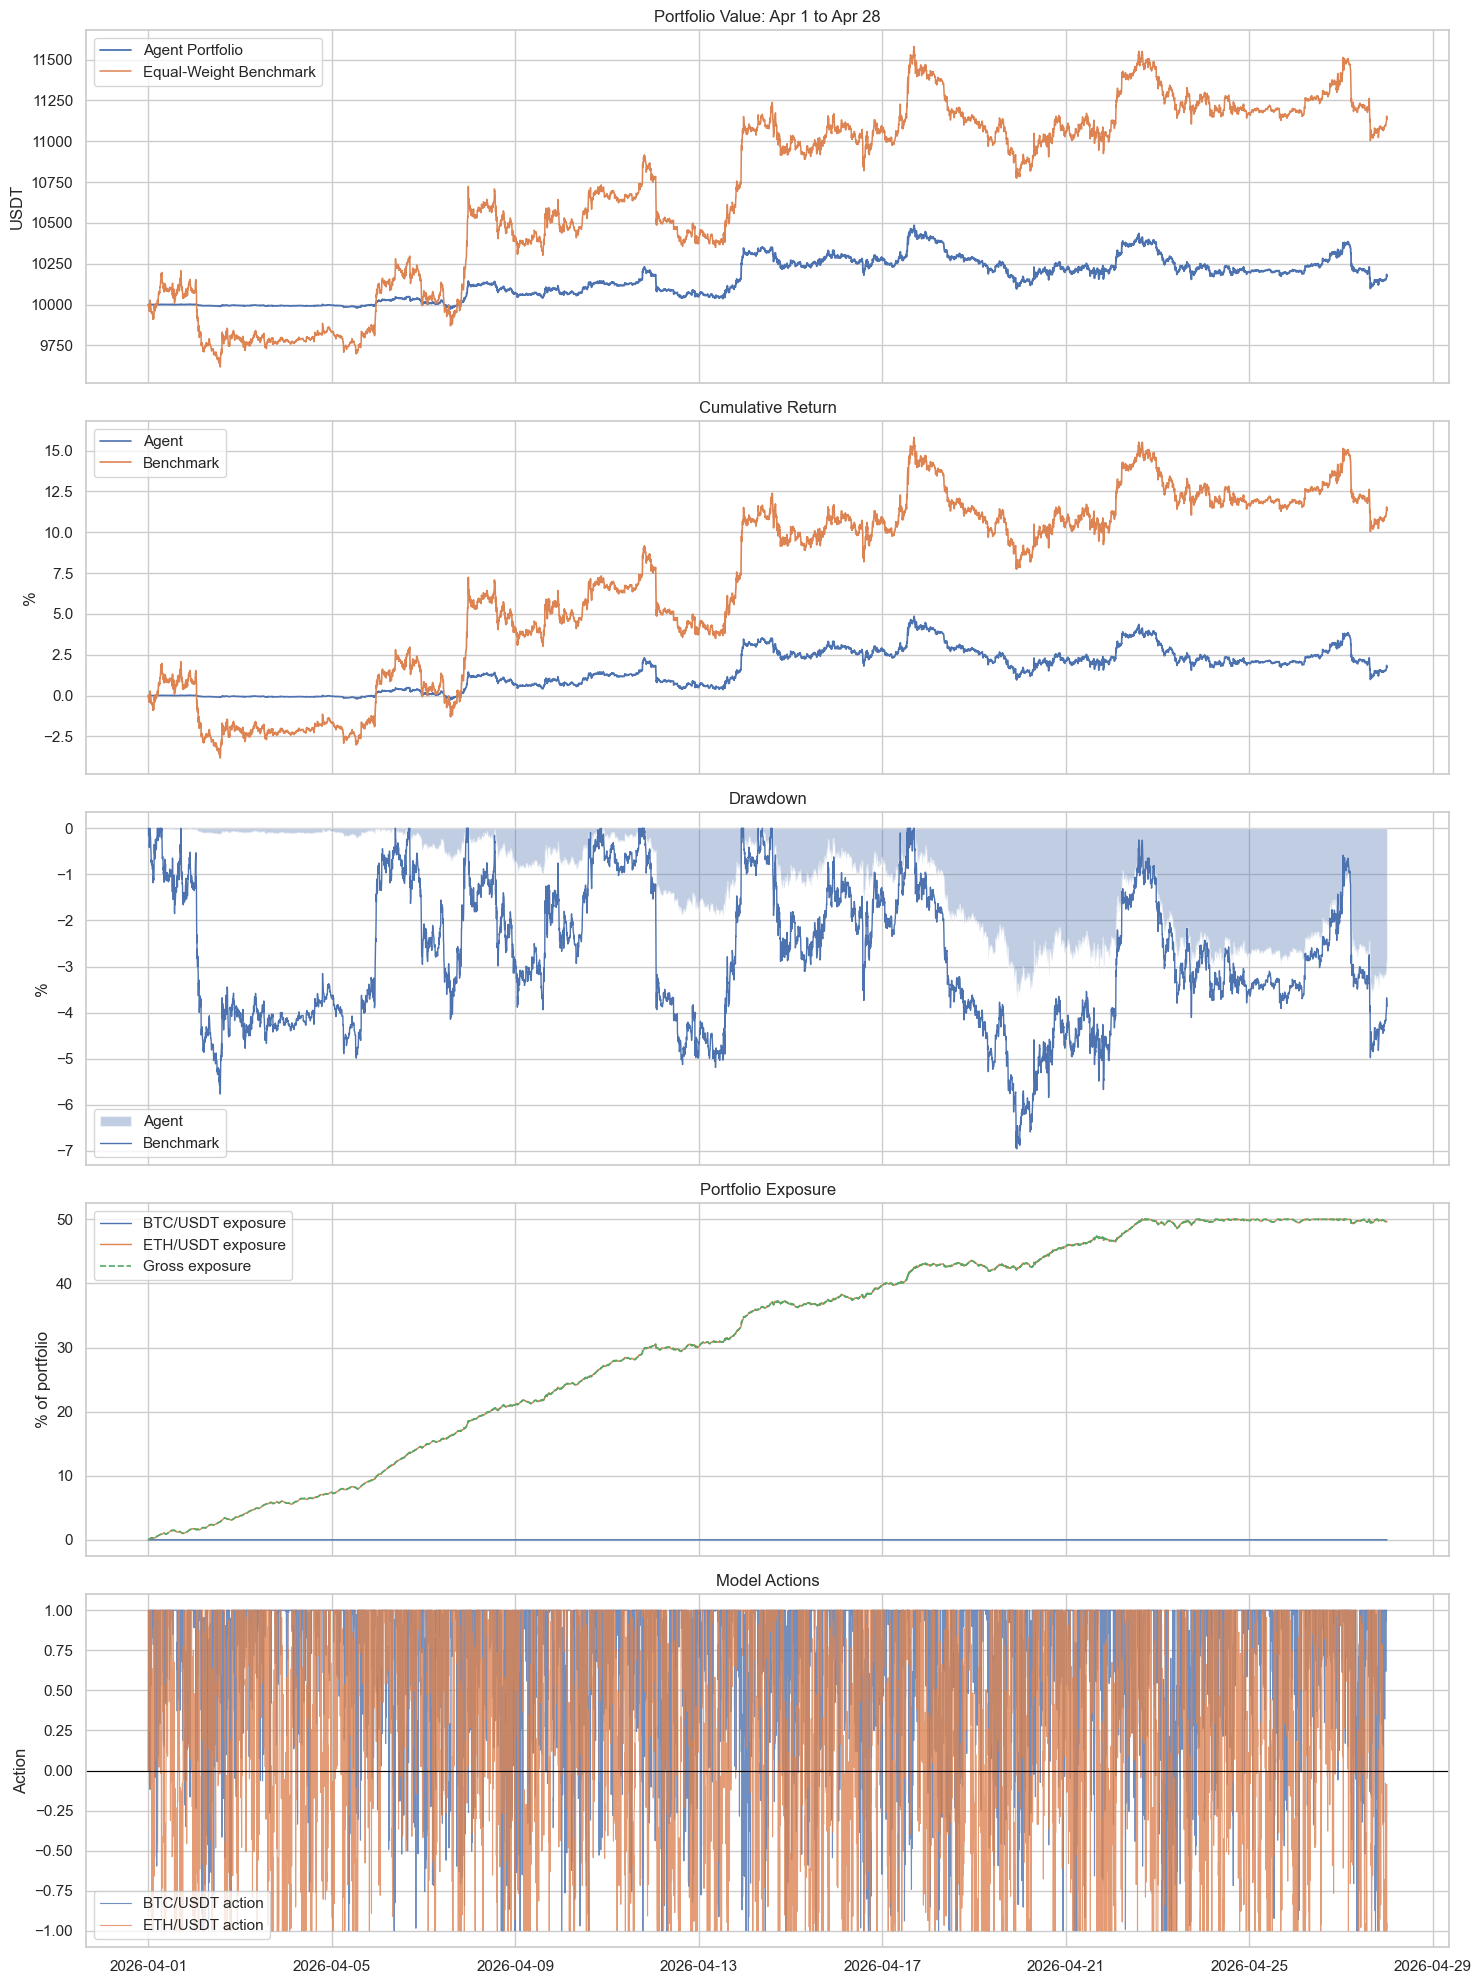

Saved combined analysis plot: /Users/dhameliyautskerarjanbhai/Documents/RL_Project/Profit-Pilot/reports/local_5m_2024_2026/plots/profit_pilot_recurrent_ppo_5m_local_2024_2026_test_2026_0401_0428_analysis.png


In [33]:
sns.set_theme(style='whitegrid')

plot_frame = test_results.copy()
plot_frame['datetime'] = pd.to_datetime(plot_frame['datetime'], utc=True)
rolling_window = 12 * 24 * 7
plot_frame['agent_7d_return'] = plot_frame['portfolio_value'] / plot_frame['portfolio_value'].shift(rolling_window) - 1.0
plot_frame['benchmark_7d_return'] = plot_frame['benchmark_value'] / plot_frame['benchmark_value'].shift(rolling_window) - 1.0

fig, axes = plt.subplots(5, 1, figsize=(15, 20), sharex=True)

axes[0].plot(plot_frame['datetime'], plot_frame['portfolio_value'], label='Agent Portfolio', linewidth=1.3)
axes[0].plot(plot_frame['datetime'], plot_frame['benchmark_value'], label='Equal-Weight Benchmark', linewidth=1.1)
axes[0].set_title('Portfolio Value: Apr 1 to Apr 28')
axes[0].set_ylabel('USDT')
axes[0].legend()

axes[1].plot(plot_frame['datetime'], plot_frame['agent_cumulative_return'] * 100, label='Agent', linewidth=1.2)
axes[1].plot(plot_frame['datetime'], plot_frame['benchmark_cumulative_return'] * 100, label='Benchmark', linewidth=1.2)
axes[1].set_title('Cumulative Return')
axes[1].set_ylabel('%')
axes[1].legend()

axes[2].fill_between(plot_frame['datetime'], plot_frame['agent_drawdown'] * 100, 0, alpha=0.35, label='Agent')
axes[2].plot(plot_frame['datetime'], plot_frame['benchmark_drawdown'] * 100, label='Benchmark', linewidth=1.0)
axes[2].set_title('Drawdown')
axes[2].set_ylabel('%')
axes[2].legend()

for symbol in SYMBOLS:
    slug = symbol_slug(symbol)
    axes[3].plot(plot_frame['datetime'], plot_frame[f'exposure_{slug}'] * 100, label=f'{symbol} exposure', linewidth=1.0)
axes[3].plot(plot_frame['datetime'], plot_frame['gross_exposure'] * 100, label='Gross exposure', linewidth=1.2, linestyle='--')
axes[3].set_title('Portfolio Exposure')
axes[3].set_ylabel('% of portfolio')
axes[3].legend()

for symbol in SYMBOLS:
    slug = symbol_slug(symbol)
    axes[4].plot(plot_frame['datetime'], plot_frame[f'action_{slug}'], label=f'{symbol} action', linewidth=0.8, alpha=0.8)
axes[4].axhline(0, color='black', linewidth=0.8)
axes[4].set_title('Model Actions')
axes[4].set_ylabel('Action')
axes[4].legend()

plt.tight_layout()
combined_plot_path = PLOT_DIR / f'{MODEL_NAME}_test_2026_0401_0428_analysis.png'
fig.savefig(combined_plot_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved combined analysis plot: {combined_plot_path}')

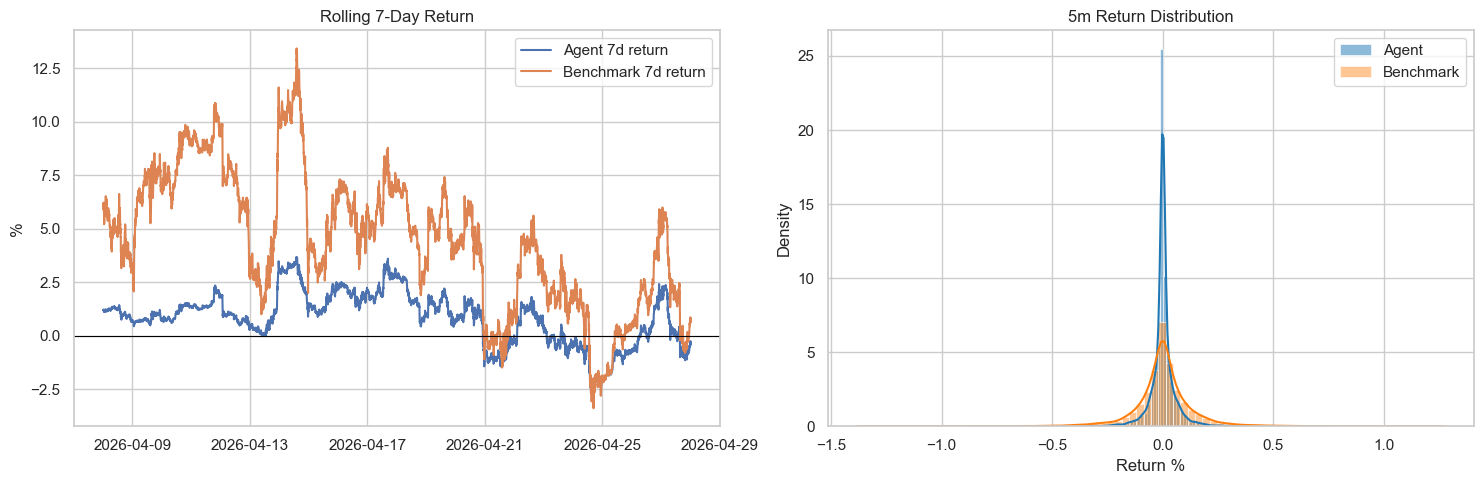

Saved risk diagnostics plot: /Users/dhameliyautskerarjanbhai/Documents/RL_Project/Profit-Pilot/reports/local_5m_2024_2026/plots/profit_pilot_recurrent_ppo_5m_local_2024_2026_test_2026_0401_0428_risk_diagnostics.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(plot_frame['datetime'], plot_frame['agent_7d_return'] * 100, label='Agent 7d return')
axes[0].plot(plot_frame['datetime'], plot_frame['benchmark_7d_return'] * 100, label='Benchmark 7d return')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Rolling 7-Day Return')
axes[0].set_ylabel('%')
axes[0].legend()

sns.histplot(plot_frame['agent_return'] * 100, bins=80, kde=True, ax=axes[1], label='Agent', color='tab:blue', stat='density')
sns.histplot(plot_frame['benchmark_return'] * 100, bins=80, kde=True, ax=axes[1], label='Benchmark', color='tab:orange', stat='density', alpha=0.45)
axes[1].set_title('5m Return Distribution')
axes[1].set_xlabel('Return %')
axes[1].legend()

plt.tight_layout()
risk_plot_path = PLOT_DIR / f'{MODEL_NAME}_test_2026_0401_0428_risk_diagnostics.png'
fig.savefig(risk_plot_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved risk diagnostics plot: {risk_plot_path}')

## Artifact Summary

Use these files for your report or presentation. The most important output is the Apr 1 to Apr 28 out-of-sample metrics JSON plus the combined analysis plot.

In [35]:
artifact_summary = {
    'model_zip': str(MODEL_PATH) + '.zip',
    'training_summary': str(MODEL_DIR / f'{MODEL_NAME}_training_summary.json'),
    'test_results_csv': str(test_csv_path),
    'test_metrics_json': str(metrics_path),
    'combined_analysis_plot': str(combined_plot_path),
    'risk_diagnostics_plot': str(risk_plot_path),
    'train_processed_bundle': str(train_bundle['root']),
    'test_processed_bundle': str(test_bundle['root']),
}
display(pd.DataFrame(artifact_summary.items(), columns=['artifact', 'path']))
with (REPORT_DIR / f'{MODEL_NAME}_artifact_summary.json').open('w', encoding='utf-8') as handle:
    json.dump(artifact_summary, handle, indent=2)

,artifact,path
0,model_zip,/Users/dhameliyautskerarjanbhai/Documents/RL_P...
1,training_summary,/Users/dhameliyautskerarjanbhai/Documents/RL_P...
2,test_results_csv,/Users/dhameliyautskerarjanbhai/Documents/RL_P...
3,test_metrics_json,/Users/dhameliyautskerarjanbhai/Documents/RL_P...
4,combined_analysis_plot,/Users/dhameliyautskerarjanbhai/Documents/RL_P...
5,risk_diagnostics_plot,/Users/dhameliyautskerarjanbhai/Documents/RL_P...
6,train_processed_bundle,/Users/dhameliyautskerarjanbhai/Documents/RL_P...
7,test_processed_bundle,/Users/dhameliyautskerarjanbhai/Documents/RL_P...


## Optional: Final Full-Window Retrain

Run this only after the out-of-sample test looks good. It trains a final artifact on the complete requested data window from `2024-01-01` through `2026-04-28`. This final model is not used for the worthiness test because it has seen the test period.

In [36]:
if RUN_FINAL_FULL_WINDOW_RETRAIN:
    full_frames = split_symbol_frames(full_symbol_frames, DATA_START_ISO, DATA_END_ISO, inclusive_end=True)
    full_bundle, _ = build_normalized_feature_bundle(
        full_frames,
        PROCESSED_FULL_ROOT,
        DATA_START_ISO,
        DATA_END_ISO,
        label='full_2024_0101_2026_0428',
    )
    full_env = make_vec_env(full_bundle)
    final_name = f'{MODEL_NAME}_full_window'
    final_path = MODEL_DIR / final_name
    if USE_LSTM:
        final_model = RecurrentPPO(
            'MlpLstmPolicy',
            env=full_env,
            verbose=1,
            learning_rate=3e-4,
            n_steps=4096,
            batch_size=1024,
            gamma=0.995,
            gae_lambda=0.95,
            clip_range=0.2,
            ent_coef=0.01,
            device=DEVICE,
        )
    else:
        final_model = PPO(
            'MlpPolicy',
            env=full_env,
            verbose=1,
            learning_rate=3e-4,
            n_steps=4096,
            batch_size=1024,
            gamma=0.995,
            gae_lambda=0.95,
            clip_range=0.2,
            ent_coef=0.01,
            device=DEVICE,
            policy_kwargs={'net_arch': [256, 256]},
        )
    final_model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True)
    final_model.save(final_path)
    full_env.close()
    print(f'Saved final full-window model: {final_path}.zip')
else:
    print('Skipped final full-window retrain. Set PROFIT_PILOT_FULL_WINDOW_RETRAIN=1 after the test metrics are acceptable.')

Skipped final full-window retrain. Set PROFIT_PILOT_FULL_WINDOW_RETRAIN=1 after the test metrics are acceptable.
